In [1]:
%load_ext autoreload
%autoreload 2

In [2]:

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import importlib
import numpy as np
from sklearn.datasets import make_blobs, make_circles, make_moons, load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

import importlib

import models.SCS
import models.Pegasos
import models.SGD

importlib.reload(models.SCS)
importlib.reload(models.Pegasos)
importlib.reload(models.SGD)

from models.Kernels import LinearKernel, RBFKernel
from models.SCS import StochasticConjugateSubgradientAlgorithm
from models.Pegasos import PegasosBaseline
from models.SGD import SGDBaseline

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

Helper functions

In [3]:
def plot_dataset(X, y, title="Dataset"): 
    plt.figure(figsize=(6,6)) 
    plt.scatter( X[y == -1, 0], X[y == -1, 1], label="-1" ) 
    plt.scatter( X[y == 1, 0], X[y == 1, 1], label="+1" ) 
    plt.title(title) 
    plt.legend() 
    plt.show()


def plot_decision_boundary(model, X, y, title="Decision Boundary"): 
    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1 
    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1 
    xx, yy = np.meshgrid( np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300) ) 
    grid = np.c_[xx.ravel(), yy.ravel()] 
    print(grid.shape)
    preds = model.predict(grid) 
    preds = preds.reshape(xx.shape) 
    plt.figure(figsize=(7,7)) 
    plt.contourf(xx, yy, preds, alpha=0.3) 
    plt.scatter( X[y == -1, 0], X[y == -1, 1], label="-1" ) 
    plt.scatter( X[y == 1, 0], X[y == 1, 1], label="+1" ) 
    plt.title(title) 
    plt.legend() 
    plt.show()

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name="Model", fit_kwargs=None): 
    if fit_kwargs is None: 
        fit_kwargs = {}
    print(fit_kwargs)
    model.fit(X_train, y_train, **fit_kwargs) 
    train_preds = model.predict(X_train) 
    print("=======")
    test_preds = model.predict(X_test) 
    train_acc = accuracy_score(y_train, train_preds) 
    test_acc = accuracy_score(y_test, test_preds) 
    print(model_name) 
    print(f"Train accuracy: {train_acc:.4f}") 
    print(f"Test accuracy : {test_acc:.4f}") 
    print("\nClassification report:") 
    print(classification_report(y_test, test_preds)) 
    if (X_train.shape[1] == 2):
        plot_decision_boundary( model, X_train, y_train, title=f"{model_name} - decision boundary")

def plot_convergence(models, labels):
    plt.figure(figsize=(8,6))
    for model, label in zip(models, labels):
        plt.plot(
            model.history,
            label=label
        )
    plt.xlabel("Iteration")
    plt.ylabel("Objective value")
    plt.title("Convergence comparison")

    plt.legend()
    plt.show()

## Dataset 1 - blobs, linearly separable case

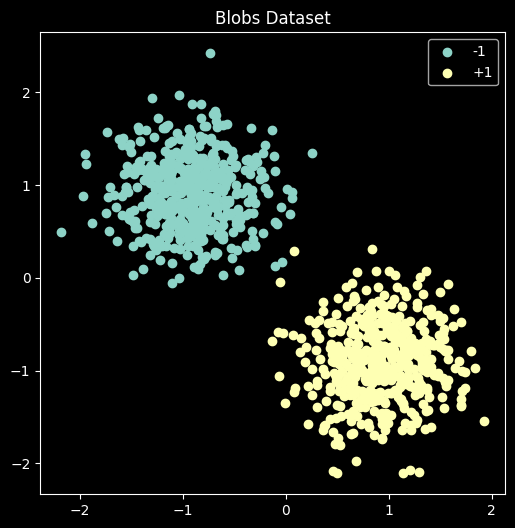

In [4]:
X, y = make_blobs(n_samples=1000, centers=2, cluster_std=1.5, random_state=42)
y = 2*y - 1

scaler = StandardScaler() 
X = scaler.fit_transform(X)

plot_dataset(X, y, "Blobs Dataset")

In [32]:
scsg_model = StochasticConjugateSubgradientAlgorithm(kernel=LinearKernel())
scsg_model.fit(X_train, y_train,max_iter=20,batch_size=8,record_history=True)

Insufficient samples remaining to construct validation batch T_k.


In [33]:
scsg_model.history

[np.float64(0.9999999999999842),
 np.float64(0.9999999999999842),
 np.float64(0.4613918103999545),
 np.float64(0.4613918103999545),
 np.float64(0.4613918103999545),
 np.float64(0.4613918103999545),
 np.float64(0.4613918103999545),
 np.float64(0.4613918103999545),
 np.float64(0.4613918103999545),
 np.float64(0.4613918103999545),
 np.float64(0.4613918103999545)]

{'max_iter': 200, 'precompute_kernel': True}
SGD - Blobs
Train accuracy: 0.9975
Test accuracy : 1.0000

Classification report:
              precision    recall  f1-score   support

          -1       1.00      1.00      1.00       103
           1       1.00      1.00      1.00        97

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

(90000, 2)


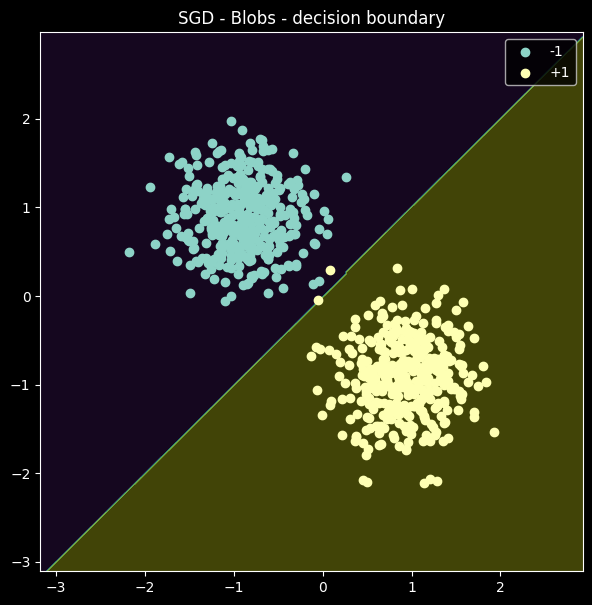

{'max_iter': 200, 'precompute_kernel': True}
Pegasos - Blobs
Train accuracy: 0.9975
Test accuracy : 1.0000

Classification report:
              precision    recall  f1-score   support

          -1       1.00      1.00      1.00       103
           1       1.00      1.00      1.00        97

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

(90000, 2)


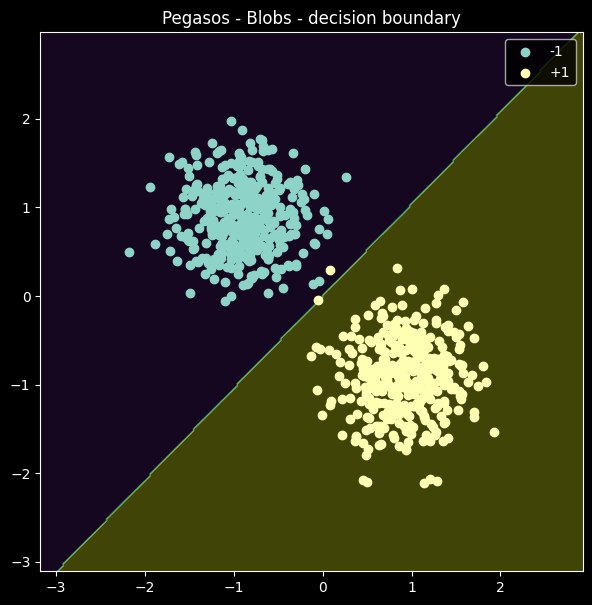

{'max_iter': 100, 'batch_size': 8}
Insufficient samples remaining to construct validation batch T_k.
SCSG - Blobs
Train accuracy: 0.9975
Test accuracy : 1.0000

Classification report:
              precision    recall  f1-score   support

          -1       1.00      1.00      1.00       103
           1       1.00      1.00      1.00        97

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

(90000, 2)


C:\Users\18pep\Documents\Sem_I\MO\SCS_Algorithm_for_kernel_SVM\models\SCS.py:114: RuntimeWarning: invalid value encountered in multiply
  alpha_new=alpha+step_t*d
C:\Users\18pep\Documents\Sem_I\MO\SCS_Algorithm_for_kernel_SVM\models\SCS.py:117: RuntimeWarning: invalid value encountered in scalar multiply
  int_L=(f_new-f_val)<=-self.m1*np.dot(d,d)*step_t
C:\Users\18pep\Documents\Sem_I\MO\SCS_Algorithm_for_kernel_SVM\models\SCS.py:132: RuntimeWarning: invalid value encountered in scalar multiply
  if t*norm_d >delta_k:
C:\Users\18pep\Documents\Sem_I\MO\SCS_Algorithm_for_kernel_SVM\models\SCS.py:51: RuntimeWarning: invalid value encountered in multiply
  alpha_hat_new=alpha_hat+t_k*d_vec


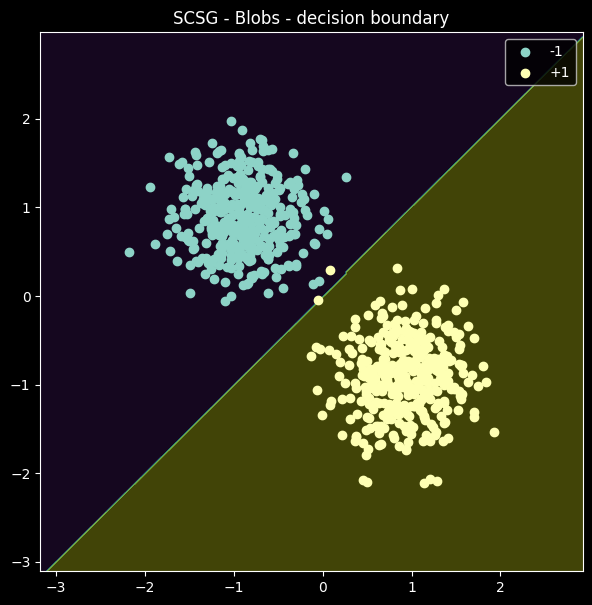

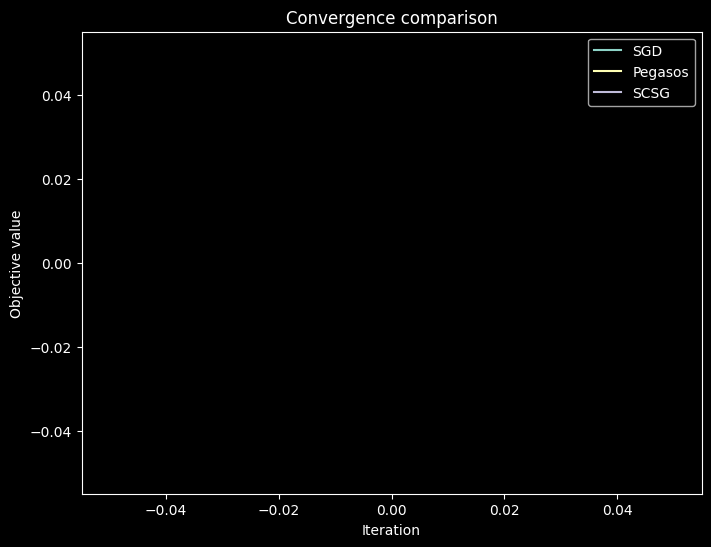

In [34]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)
sgd_model = SGDBaseline(kernel=LinearKernel(), eta=0.0001)
evaluate_model( sgd_model, X_train, X_test, y_train, y_test, model_name="SGD - Blobs", fit_kwargs={ "max_iter": 200, "precompute_kernel": True })

pegasos_model = PegasosBaseline(kernel=LinearKernel()) 
evaluate_model( pegasos_model, X_train, X_test, y_train, y_test, model_name="Pegasos - Blobs", fit_kwargs={ "max_iter": 200, "precompute_kernel": True })

scsg_model = StochasticConjugateSubgradientAlgorithm(kernel=LinearKernel())
evaluate_model(scsg_model, X_train, X_test, y_train, y_test, model_name="SCSG - Blobs", fit_kwargs={ "max_iter": 100, "batch_size": 8 })


plot_convergence(
    [sgd_model, pegasos_model, scsg_model],
    ["SGD", "Pegasos", "SCSG"]
)

{'max_iter': 100, 'batch_size': 8}
Insufficient samples remaining to construct validation batch T_k.
SCSG - Blobs
Train accuracy: 0.9975
Test accuracy : 1.0000

Classification report:
              precision    recall  f1-score   support

          -1       1.00      1.00      1.00       103
           1       1.00      1.00      1.00        97

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

(90000, 2)


C:\Users\18pep\Documents\Sem_I\MO\SCS_Algorithm_for_kernel_SVM\models\SCS.py:114: RuntimeWarning: invalid value encountered in multiply
  alpha_new=alpha+step_t*d
C:\Users\18pep\Documents\Sem_I\MO\SCS_Algorithm_for_kernel_SVM\models\SCS.py:117: RuntimeWarning: invalid value encountered in scalar multiply
  int_L=(f_new-f_val)<=-self.m1*np.dot(d,d)*step_t
C:\Users\18pep\Documents\Sem_I\MO\SCS_Algorithm_for_kernel_SVM\models\SCS.py:132: RuntimeWarning: invalid value encountered in scalar multiply
  if t*norm_d >delta_k:
C:\Users\18pep\Documents\Sem_I\MO\SCS_Algorithm_for_kernel_SVM\models\SCS.py:51: RuntimeWarning: invalid value encountered in multiply
  alpha_hat_new=alpha_hat+t_k*d_vec


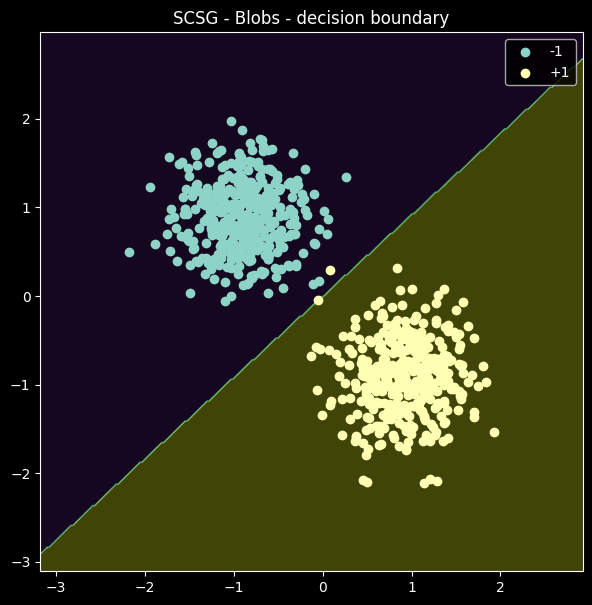

In [6]:
scsg_model = StochasticConjugateSubgradientAlgorithm(kernel=LinearKernel())
evaluate_model(scsg_model, X_train, X_test, y_train, y_test, model_name="SCSG - Blobs", fit_kwargs={ "max_iter": 100, "batch_size": 8 })

In [7]:
scsg_model.alpha

array([-0.03326606,  0.03361257, -0.02723523, -0.0332143 , -0.02830866,
        0.02923483, -0.01619676,  0.01863252, -0.03403123, -0.02052939,
        0.01974424, -0.02410424, -0.0028785 , -0.00294912,  0.0389262 ,
        0.0211258 , -0.01901334, -0.02433481, -0.02537314,  0.02608247,
       -0.02770089, -0.0240706 , -0.01688188,  0.02897554,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.  

## Dataset 2 - moons, not linearly separable case

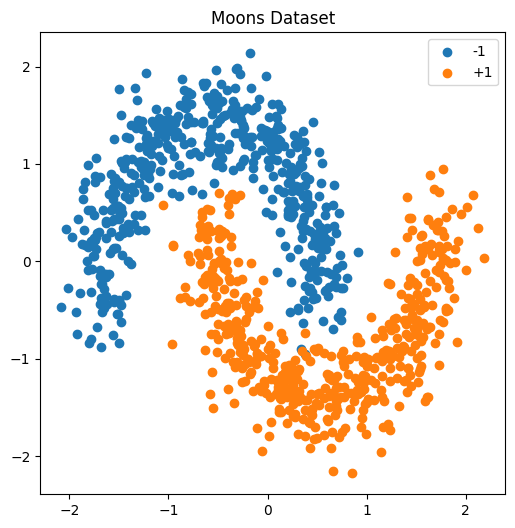

In [76]:
X, y = make_moons(n_samples=1000, noise=0.15, random_state=42 ) 
y = 2*y - 1

scaler = StandardScaler() 
X = scaler.fit_transform(X)

plot_dataset(X, y, "Moons Dataset")

{'max_iter': 100, 'precompute_kernel': True}
SGD Linear - Moons
Train accuracy: 0.8712
Test accuracy : 0.8550

Classification report:
              precision    recall  f1-score   support

          -1       0.86      0.85      0.85       100
           1       0.85      0.86      0.86       100

    accuracy                           0.85       200
   macro avg       0.86      0.85      0.85       200
weighted avg       0.86      0.85      0.85       200

(90000, 2)


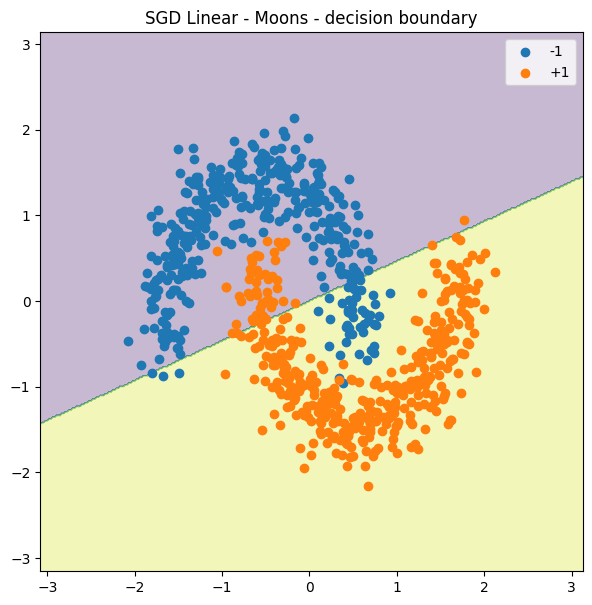

{'max_iter': 100, 'precompute_kernel': True}
SGD RBF - Moons
Train accuracy: 0.9600
Test accuracy : 0.9700

Classification report:
              precision    recall  f1-score   support

          -1       0.97      0.97      0.97       100
           1       0.97      0.97      0.97       100

    accuracy                           0.97       200
   macro avg       0.97      0.97      0.97       200
weighted avg       0.97      0.97      0.97       200

(90000, 2)


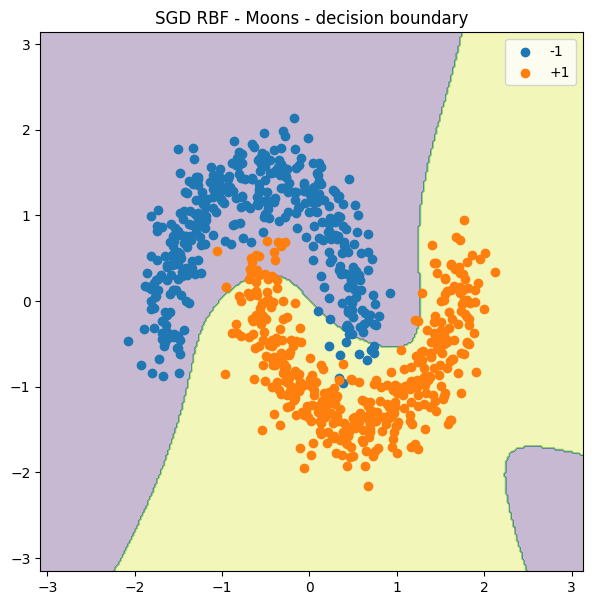

{'max_iter': 100, 'precompute_kernel': True}
Pegasos RBF - Moons
Train accuracy: 0.9600
Test accuracy : 0.9650

Classification report:
              precision    recall  f1-score   support

          -1       0.95      0.98      0.97       100
           1       0.98      0.95      0.96       100

    accuracy                           0.96       200
   macro avg       0.97      0.96      0.96       200
weighted avg       0.97      0.96      0.96       200

(90000, 2)


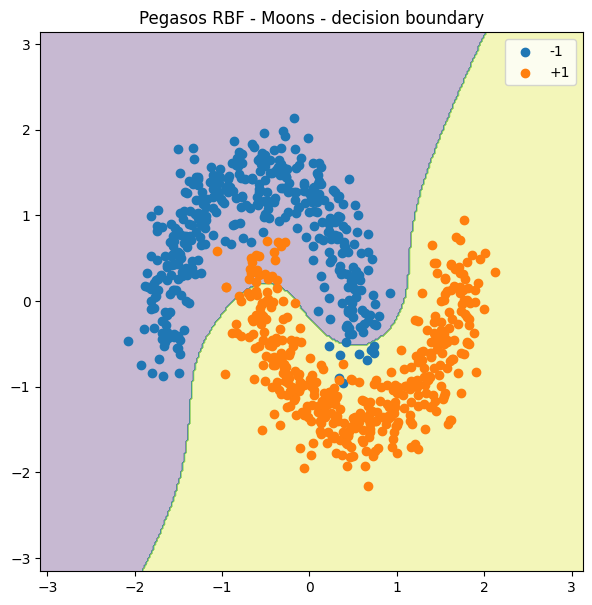

{'max_iter': 100, 'batch_size': 8}


c:\Users\basiu\OneDrive\Pulpit\sem 8\optimization\Stochastic_Conjugete_subgradient_algorithm_for_kernel_SVM\models\SCS.py:126: RuntimeWarning: invalid value encountered in multiply
  alpha_new=alpha+step_t*d
c:\Users\basiu\OneDrive\Pulpit\sem 8\optimization\Stochastic_Conjugete_subgradient_algorithm_for_kernel_SVM\models\SCS.py:129: RuntimeWarning: invalid value encountered in scalar multiply
  int_L=(f_new-f_val)<=-self.m1*np.dot(d,d)*step_t
c:\Users\basiu\OneDrive\Pulpit\sem 8\optimization\Stochastic_Conjugete_subgradient_algorithm_for_kernel_SVM\models\SCS.py:144: RuntimeWarning: invalid value encountered in scalar multiply
  if t*norm_d >delta_k:
c:\Users\basiu\OneDrive\Pulpit\sem 8\optimization\Stochastic_Conjugete_subgradient_algorithm_for_kernel_SVM\models\SCS.py:56: RuntimeWarning: invalid value encountered in multiply
  alpha_hat_new=alpha_hat+t_k*d_vec


Insufficient samples remaining to construct validation batch T_k.
SCSG RBF - Moons
Train accuracy: 0.9537
Test accuracy : 0.9600

Classification report:
              precision    recall  f1-score   support

          -1       0.99      0.93      0.96       100
           1       0.93      0.99      0.96       100

    accuracy                           0.96       200
   macro avg       0.96      0.96      0.96       200
weighted avg       0.96      0.96      0.96       200

(90000, 2)


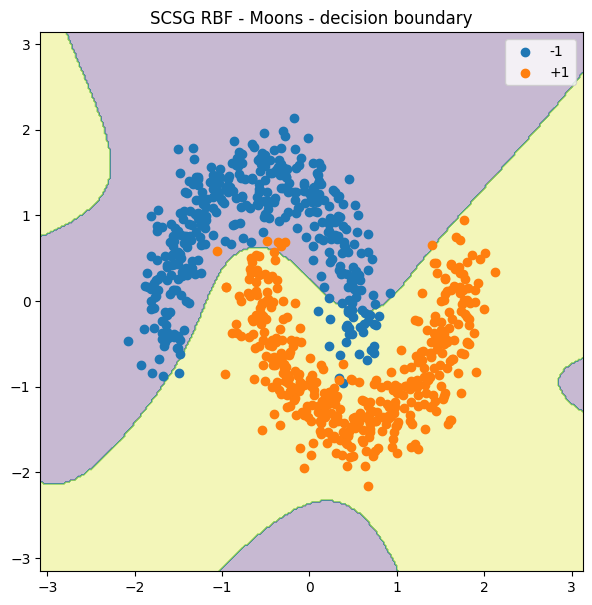

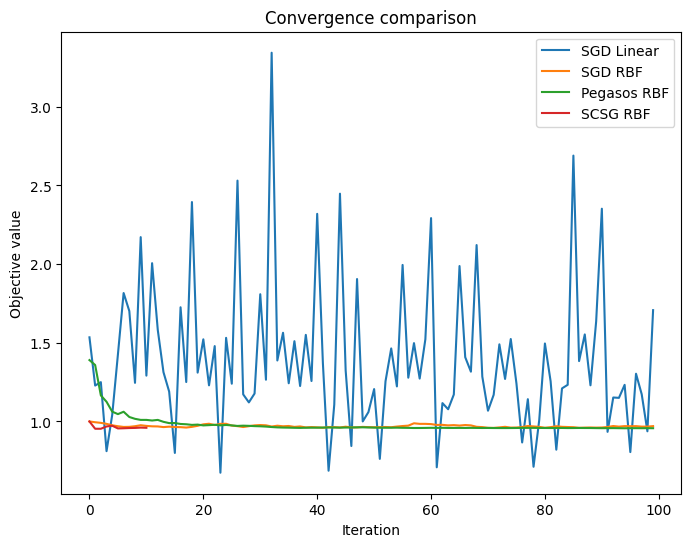

In [77]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

sgd_model_linear = SGDBaseline( kernel=LinearKernel(), eta=0.001)
evaluate_model( sgd_model_linear, X_train, X_test, y_train, y_test, model_name="SGD Linear - Moons", fit_kwargs={ "max_iter": 100, "precompute_kernel": True })

sgd_model_rbf = SGDBaseline( kernel=RBFKernel(gamma_rbf=2.0), eta=0.001)
evaluate_model( sgd_model_rbf, X_train, X_test, y_train, y_test, model_name="SGD RBF - Moons", fit_kwargs={ "max_iter": 100, "precompute_kernel": True })

pegasos_model = PegasosBaseline( kernel=RBFKernel(gamma_rbf=2.0))
evaluate_model( pegasos_model, X_train, X_test, y_train, y_test, model_name="Pegasos RBF - Moons", fit_kwargs={ "max_iter": 100, "precompute_kernel": True })

scsg_model = StochasticConjugateSubgradientAlgorithm( kernel=RBFKernel(gamma_rbf=2.0))
evaluate_model( scsg_model, X_train, X_test, y_train, y_test, model_name="SCSG RBF - Moons", fit_kwargs={ "max_iter": 100, "batch_size": 8 })

plot_convergence(
    [sgd_model_linear, sgd_model_rbf, pegasos_model, scsg_model],
    ["SGD Linear", "SGD RBF", "Pegasos RBF", "SCSG RBF"]
)

## Dataset 3 - circles

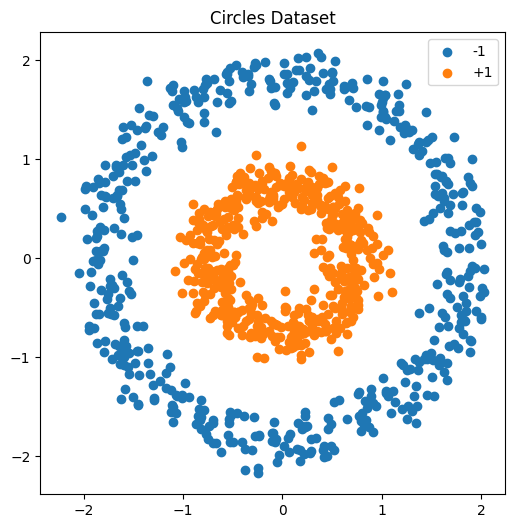

In [78]:
X, y = make_circles( n_samples=1000, factor=0.4, noise=0.08, random_state=42 ) 
y = 2*y - 1

scaler = StandardScaler()
X = scaler.fit_transform(X)

plot_dataset(X, y, "Circles Dataset")

{'max_iter': 100, 'precompute_kernel': True}
SGD RBF - Circles
Train accuracy: 0.9962
Test accuracy : 0.9950

Classification report:
              precision    recall  f1-score   support

          -1       1.00      0.99      0.99       100
           1       0.99      1.00      1.00       100

    accuracy                           0.99       200
   macro avg       1.00      0.99      0.99       200
weighted avg       1.00      0.99      0.99       200

(90000, 2)


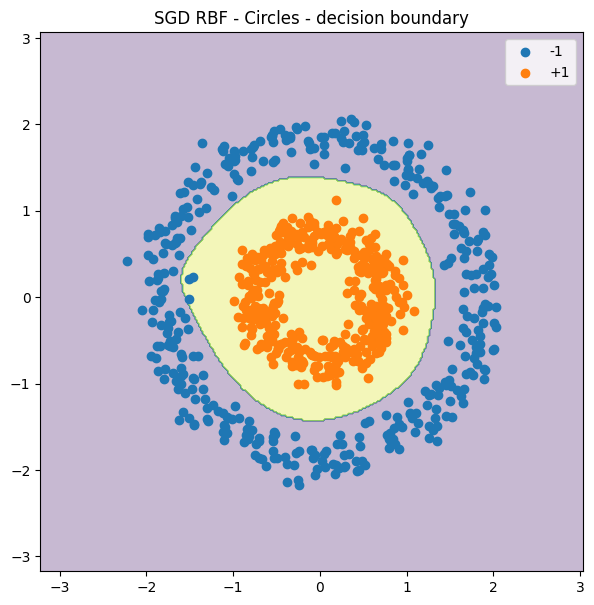

{'max_iter': 100, 'precompute_kernel': True}
Pegasos RBF - Circles
Train accuracy: 0.9975
Test accuracy : 1.0000

Classification report:
              precision    recall  f1-score   support

          -1       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

(90000, 2)


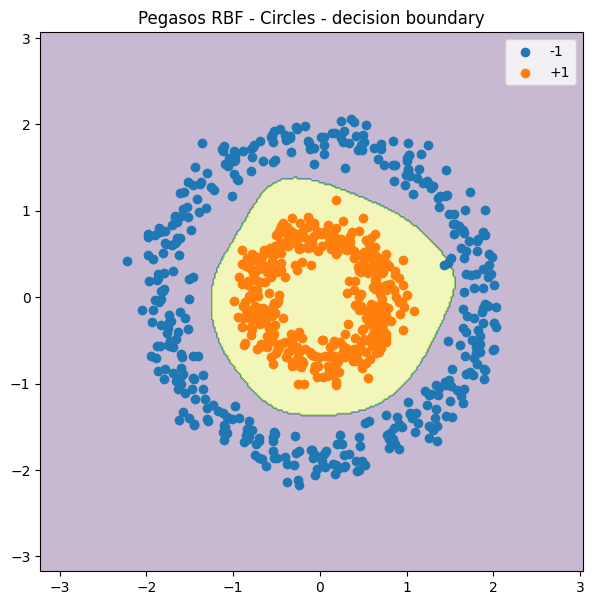

{'max_iter': 100, 'batch_size': 8}
Insufficient samples remaining to construct validation batch T_k.


c:\Users\basiu\OneDrive\Pulpit\sem 8\optimization\Stochastic_Conjugete_subgradient_algorithm_for_kernel_SVM\models\SCS.py:126: RuntimeWarning: invalid value encountered in multiply
  alpha_new=alpha+step_t*d
c:\Users\basiu\OneDrive\Pulpit\sem 8\optimization\Stochastic_Conjugete_subgradient_algorithm_for_kernel_SVM\models\SCS.py:129: RuntimeWarning: invalid value encountered in scalar multiply
  int_L=(f_new-f_val)<=-self.m1*np.dot(d,d)*step_t
c:\Users\basiu\OneDrive\Pulpit\sem 8\optimization\Stochastic_Conjugete_subgradient_algorithm_for_kernel_SVM\models\SCS.py:144: RuntimeWarning: invalid value encountered in scalar multiply
  if t*norm_d >delta_k:
c:\Users\basiu\OneDrive\Pulpit\sem 8\optimization\Stochastic_Conjugete_subgradient_algorithm_for_kernel_SVM\models\SCS.py:56: RuntimeWarning: invalid value encountered in multiply
  alpha_hat_new=alpha_hat+t_k*d_vec


SCSG RBF - Circles
Train accuracy: 0.8725
Test accuracy : 0.8900

Classification report:
              precision    recall  f1-score   support

          -1       1.00      0.78      0.88       100
           1       0.82      1.00      0.90       100

    accuracy                           0.89       200
   macro avg       0.91      0.89      0.89       200
weighted avg       0.91      0.89      0.89       200

(90000, 2)


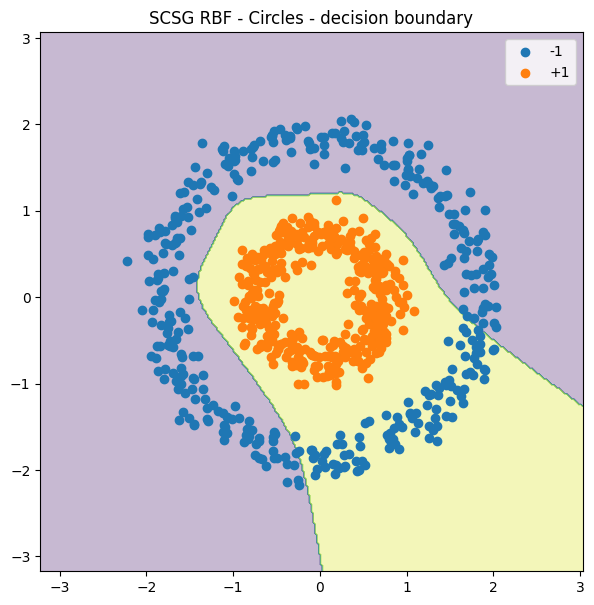

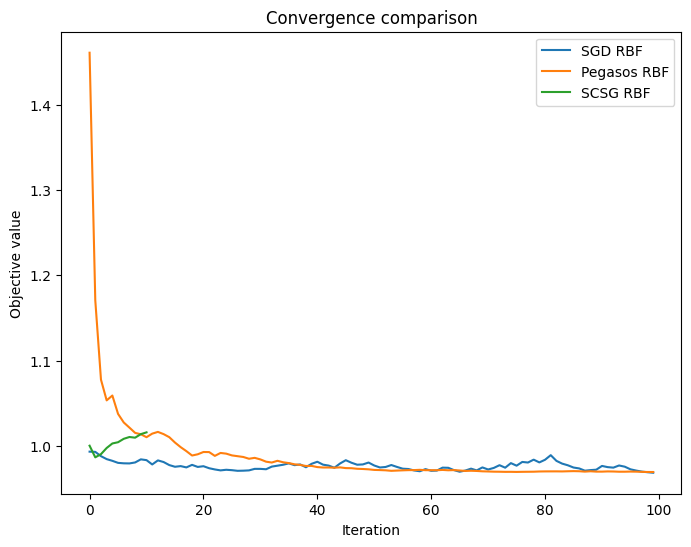

In [79]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)
gamma = 3.0

sgd_model_rbf = SGDBaseline( kernel=RBFKernel(gamma_rbf=gamma), eta=0.001)
evaluate_model( sgd_model_rbf, X_train, X_test, y_train, y_test, model_name="SGD RBF - Circles", fit_kwargs={ "max_iter": 100, "precompute_kernel": True })

pegasos_model = PegasosBaseline( kernel=RBFKernel(gamma_rbf=gamma))
evaluate_model( pegasos_model, X_train, X_test, y_train, y_test, model_name="Pegasos RBF - Circles", fit_kwargs={ "max_iter": 100, "precompute_kernel": True })

scsg_model = StochasticConjugateSubgradientAlgorithm( kernel=RBFKernel(gamma_rbf=gamma))
evaluate_model( scsg_model, X_train, X_test, y_train, y_test, model_name="SCSG RBF - Circles", fit_kwargs={ "max_iter": 100, "batch_size": 8 })

plot_convergence(
    [sgd_model_rbf, pegasos_model, scsg_model],
    ["SGD RBF", "Pegasos RBF", "SCSG RBF"]
)


In [80]:
shapes=[]
for x_test in X_test:
    shapes.append(x_test.shape[0])
arr=np.array(shapes)
np.unique(arr)

array([2])

In [ ]:
X, y = load_breast_cancer(return_X_y=True)
y = 2*y - 1

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

sgd_model_linear = SGDBaseline( kernel=LinearKernel(), eta=0.001)
evaluate_model( sgd_model_linear, X_train, X_test, y_train, y_test, model_name="SGD Linear - Breast Cancer", fit_kwargs={ "max_iter": 100, "precompute_kernel": True })



{'max_iter': 100, 'precompute_kernel': True}
SGD Linear - Breast Cancer
Train accuracy: 0.0967
Test accuracy : 0.0439

Classification report:
              precision    recall  f1-score   support

          -1       0.03      0.05      0.04        43
           1       0.07      0.04      0.05        71

    accuracy                           0.04       114
   macro avg       0.05      0.04      0.04       114
weighted avg       0.05      0.04      0.05       114



In [2]:
import time
from models.data_loader import load_dataset
import pandas as pd

data = pd.read_csv("./data/Occupancy_Estimation.csv")
data['Room_Occupancy_Count'].value_counts()



Room_Occupancy_Count
0    8228
2     748
3     694
1     459
Name: count, dtype: int64

In [3]:
data['label'] = data['Room_Occupancy_Count'].apply(lambda x: 1 if x > 0 else -1)

In [4]:
data.head()

,Date,Time,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count,label
0,2017/12/22,10:49:41,24.94,24.75,24.56,25.38,121,34,53,40,0.08,0.19,0.06,0.06,390,0.769231,0,0,1,1
1,2017/12/22,10:50:12,24.94,24.75,24.56,25.44,121,33,53,40,0.93,0.05,0.06,0.06,390,0.646154,0,0,1,1
2,2017/12/22,10:50:42,25.00,24.75,24.50,25.44,121,34,53,40,0.43,0.11,0.08,0.06,390,0.519231,0,0,1,1
3,2017/12/22,10:51:13,25.00,24.75,24.56,25.44,121,34,53,40,0.41,0.10,0.10,0.09,390,0.388462,0,0,1,1
4,2017/12/22,10:51:44,25.00,24.75,24.56,25.44,121,34,54,40,0.18,0.06,0.06,0.06,390,0.253846,0,0,1,1


In [5]:
data = data.drop(columns=['Room_Occupancy_Count', 'Date', 'Time'])

In [8]:
X = data.drop(columns=['label'])
y = data['label']

In [9]:
X.head()

,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR
0,24.94,24.75,24.56,25.38,121,34,53,40,0.08,0.19,0.06,0.06,390,0.769231,0,0
1,24.94,24.75,24.56,25.44,121,33,53,40,0.93,0.05,0.06,0.06,390,0.646154,0,0
2,25.00,24.75,24.50,25.44,121,34,53,40,0.43,0.11,0.08,0.06,390,0.519231,0,0
3,25.00,24.75,24.56,25.44,121,34,53,40,0.41,0.10,0.10,0.09,390,0.388462,0,0
4,25.00,24.75,24.56,25.44,121,34,54,40,0.18,0.06,0.06,0.06,390,0.253846,0,0


In [11]:
X.to_csv("./data/room-occupancy/X.csv", index=False)
y.to_csv("./data/room-occupancy/y.csv", index=False)

In [12]:
len(X)

10129

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
X_train.shape

(8103, 16)

In [27]:
execution_times = {}

def measure_model_fit_times(model, X_train, y_train, fit_kwargs=None):
    if fit_kwargs is None:
        fit_kwargs = {}
    np.random.seed(42)
    start_time = time.time()
    model.fit(X_train, y_train, record_history=False, **fit_kwargs)
    no_log_time = time.time() - start_time

    np.random.seed(42)
    start_time = time.time()
    model.fit(X_train, y_train, record_history=True, **fit_kwargs)
    log_time = time.time() - start_time

    return no_log_time, log_time

def evaluate_model_with_timing(model, X_train, X_test, y_train, y_test, model_name="Model", fit_kwargs=None):
    if fit_kwargs is None:
        fit_kwargs = {}
    print(fit_kwargs)

    no_log_time, log_time = measure_model_fit_times(model, X_train, y_train, fit_kwargs)

    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)
    train_acc = accuracy_score(y_train, train_preds)
    test_acc = accuracy_score(y_test, test_preds)

    print("=======")
    print(model_name)
    print(f"Train accuracy: {train_acc:.4f}")
    print(f"Test accuracy : {test_acc:.4f}")
    print("\nClassification report:")
    print(classification_report(y_test, test_preds))

    if X_train.shape[1] == 2:
        plot_decision_boundary(model, X_train, y_train, title=f"{model_name} - decision boundary")

    objective_curve = getattr(model, "history", None)
    return no_log_time, log_time, objective_curve

# ---------------------------------------------------------
# 1. SGD Baseline
# ---------------------------------------------------------
sgd_model = SGDBaseline(kernel=LinearKernel(), eta=0.0001)

sgd_no_log_time, sgd_log_time, _ = evaluate_model_with_timing(
    sgd_model,
    X_train, X_test, y_train, y_test,
    model_name="SGD - Blobs",
    fit_kwargs={"max_iter": 200, "precompute_kernel": False}
)

execution_times["SGD"] = {"no_log": sgd_no_log_time, "log": sgd_log_time}
print(f"[*] SGD no-log Time: {sgd_no_log_time:.4f} seconds")
print(f"[*] SGD log Time   : {sgd_log_time:.4f} seconds\n")

# ---------------------------------------------------------
# 2. Pegasos Baseline
# ---------------------------------------------------------
pegasos_model = PegasosBaseline(kernel=LinearKernel())

pegasos_no_log_time, pegasos_log_time, _ = evaluate_model_with_timing(
    pegasos_model,
    X_train, X_test, y_train, y_test,
    model_name="Pegasos - Blobs",
    fit_kwargs={"max_iter": 200, "precompute_kernel": False}
)

execution_times["Pegasos"] = {"no_log": pegasos_no_log_time, "log": pegasos_log_time}
print(f"[*] Pegasos no-log Time: {pegasos_no_log_time:.4f} seconds")
print(f"[*] Pegasos log Time   : {pegasos_log_time:.4f} seconds\n")

# ---------------------------------------------------------
# 3. SCSG Algorithm
# ---------------------------------------------------------
scsg_model = StochasticConjugateSubgradientAlgorithm(kernel=LinearKernel())

scsg_no_log_time, scsg_log_time, _ = evaluate_model_with_timing(
    scsg_model,
    X_train, X_test, y_train, y_test,
    model_name="SCSG - Blobs",
    fit_kwargs={"max_iter": 100, "batch_size": 8}
)

execution_times["SCSG"] = {"no_log": scsg_no_log_time, "log": scsg_log_time}
print(f"[*] SCSG no-log Time: {scsg_no_log_time:.4f} seconds")
print(f"[*] SCSG log Time   : {scsg_log_time:.4f} seconds\n")

# ---------------------------------------------------------
# Summary & Plotting
# ---------------------------------------------------------
print("--- Execution Time Summary ---")
for model_name, times in execution_times.items():
    print(f"{model_name}: no logging = {times['no_log']:.4f} seconds, logging = {times['log']:.4f} seconds")

plot_convergence(
    [sgd_model, pegasos_model, scsg_model],
    ["SGD", "Pegasos", "SCSG"]
)

{'max_iter': 200, 'precompute_kernel': False}


/Users/michalwietecki/Desktop/pw/8_sem/optimization/new_repo/Stochastic_Conjugete_subgradient_algorithm_for_kernel_SVM/models/SGD.py:94: RuntimeWarning: invalid value encountered in subtract
  alpha = alpha - self.eta * gradient


SGD - Blobs
Train accuracy: 0.8156
Test accuracy : 0.7991

Classification report:
              precision    recall  f1-score   support

          -1       0.80      1.00      0.89      1619
           1       0.00      0.00      0.00       407

    accuracy                           0.80      2026
   macro avg       0.40      0.50      0.44      2026
weighted avg       0.64      0.80      0.71      2026

[*] SGD no-log Time: 67.7657 seconds
[*] SGD log Time   : 120.7043 seconds

{'max_iter': 200, 'precompute_kernel': False}


/Users/michalwietecki/Desktop/pw/8_sem/optimization/new_repo/Stochastic_Conjugete_subgradient_algorithm_for_kernel_SVM/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/michalwietecki/Desktop/pw/8_sem/optimization/new_repo/Stochastic_Conjugete_subgradient_algorithm_for_kernel_SVM/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/michalwietecki/Desktop/pw/8_sem/optimization/new_repo/Stochastic_Conjugete_subgradient_algorithm_for_kernel_SVM/.venv/lib/p

Pegasos - Blobs
Train accuracy: 0.9377
Test accuracy : 0.9334

Classification report:
              precision    recall  f1-score   support

          -1       0.92      1.00      0.96      1619
           1       1.00      0.67      0.80       407

    accuracy                           0.93      2026
   macro avg       0.96      0.83      0.88      2026
weighted avg       0.94      0.93      0.93      2026

[*] Pegasos no-log Time: 0.0065 seconds
[*] Pegasos log Time   : 0.0169 seconds

{'max_iter': 100, 'batch_size': 8}
Insufficient samples remaining to construct validation batch T_k.
Insufficient samples remaining to construct validation batch T_k.
SCSG - Blobs
Train accuracy: 0.1844
Test accuracy : 0.2009

Classification report:
              precision    recall  f1-score   support

          -1       0.00      0.00      0.00      1619
           1       0.20      1.00      0.33       407

    accuracy                           0.20      2026
   macro avg       0.10      0.50     

/Users/michalwietecki/Desktop/pw/8_sem/optimization/new_repo/Stochastic_Conjugete_subgradient_algorithm_for_kernel_SVM/models/SCS.py:120: RuntimeWarning: invalid value encountered in multiply
  alpha_new=alpha+step_t*d
/Users/michalwietecki/Desktop/pw/8_sem/optimization/new_repo/Stochastic_Conjugete_subgradient_algorithm_for_kernel_SVM/models/SCS.py:123: RuntimeWarning: invalid value encountered in scalar multiply
  int_L=(f_new-f_val)<=-self.m1*np.dot(d,d)*step_t
/Users/michalwietecki/Desktop/pw/8_sem/optimization/new_repo/Stochastic_Conjugete_subgradient_algorithm_for_kernel_SVM/models/SCS.py:138: RuntimeWarning: invalid value encountered in scalar multiply
  if t*norm_d >delta_k:
/Users/michalwietecki/Desktop/pw/8_sem/optimization/new_repo/Stochastic_Conjugete_subgradient_algorithm_for_kernel_SVM/models/SCS.py:56: RuntimeWarning: invalid value encountered in multiply
  alpha_hat_new=alpha_hat+t_k*d_vec
/Users/michalwietecki/Desktop/pw/8_sem/optimization/new_repo/Stochastic_Conjugete

NameError: name 'plot_convergence' is not defined

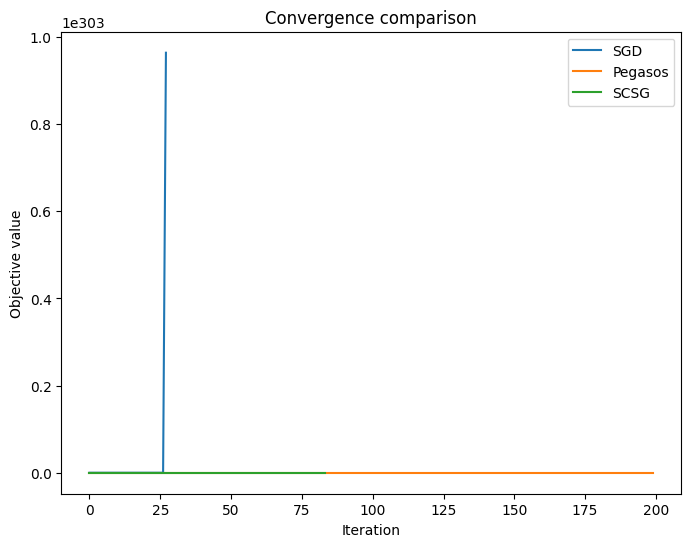

In [29]:
plot_convergence(
    [sgd_model, pegasos_model, scsg_model],
    ["SGD", "Pegasos", "SCSG"]
)

## testing again.

In [41]:
import models.data_loader
importlib.reload(models.data_loader)
from models.data_loader import load_dataset

In [42]:
X, y = load_dataset(subfolder="room-occupancy")
print(X.shape)
print(y.shape)


(10129, 16)
(10129,)


In [43]:
import numpy as np
unique, counts = np.unique(y, return_counts=True)
print(dict(zip(unique, counts)))

{np.int32(-1): np.int64(8228), np.int32(1): np.int64(1901)}


In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [69]:
sgd_model = SGDBaseline(kernel=LinearKernel(), eta=0.001)
start_time = time.time()
sgd_model.fit(X_train, y_train, max_iter = 100, precompute_kernel = False, record_history = False)
end_time = time.time()
y_pred = sgd_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("SGD Baseline")
print(f"Accuracy: {acc:.4f}")
print(f"Time taken: {end_time - start_time:.4f} seconds")


SGD Baseline
Accuracy: 0.9832
Time taken: 0.0123 seconds


In [100]:
sgd_model = SGDBaseline(kernel=RBFKernel(gamma_rbf=2.0), eta=0.0001)
start_time = time.time()
sgd_model.fit(X_train, y_train, max_iter = 100, precompute_kernel = False, record_history = False)
end_time = time.time()
y_pred = sgd_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("SGD Baseline (record history True)")
print(f"Accuracy: {acc:.4f}")
print(f"Time taken: {end_time - start_time:.4f} seconds")


SGD Baseline (record history True)
Accuracy: 0.9146
Time taken: 0.0515 seconds


In [105]:
sgd_model = SGDBaseline(kernel=LinearKernel(), eta=0.001)
start_time = time.time()
sgd_model.fit(X_train, y_train, max_iter = 100, precompute_kernel = True, record_history = False)
end_time = time.time()
y_pred = sgd_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("SGD Baseline")
print(f"Accuracy: {acc:.4f}")
print(f"Time taken: {end_time - start_time:.4f} seconds")

print("")
print("")
print("")

sgd_model = SGDBaseline(kernel=LinearKernel(), eta=0.001)
start_time = time.time()
sgd_model.fit(X_train, y_train, max_iter = 100, precompute_kernel = True, record_history = True)
end_time = time.time()
y_pred = sgd_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("SGD Baseline (record history True)")
print(f"Accuracy: {acc:.4f}")
print(f"Time taken: {end_time - start_time:.4f} seconds")



SGD Baseline
Accuracy: 0.9773
Time taken: 0.4354 seconds



SGD Baseline (record history True)
Accuracy: 0.9408
Time taken: 0.4440 seconds


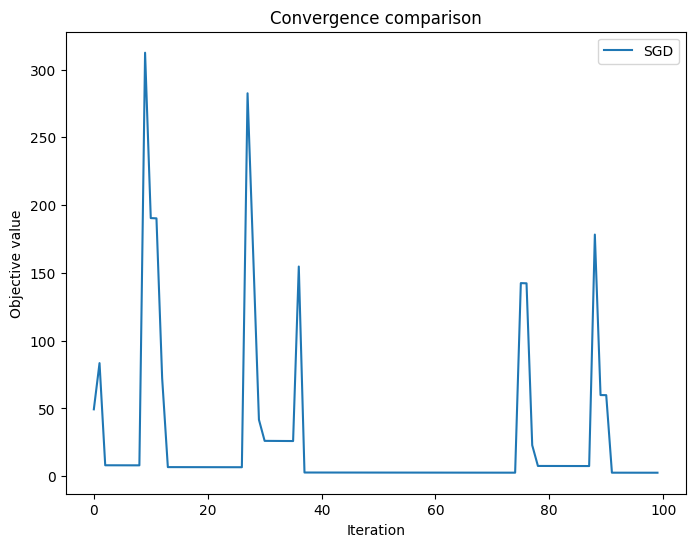

In [106]:
plot_convergence(
    [sgd_model],
    ["SGD"]
)

In [115]:
sgd_model = SGDBaseline(kernel=RBFKernel(gamma_rbf=2.0), eta=0.005)
start_time = time.time()
sgd_model.fit(X_train, y_train, max_iter = 1000, precompute_kernel = False, record_history = True)
end_time = time.time()
y_pred = sgd_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("SGD Baseline (record history True)")
print(f"Accuracy: {acc:.4f}")
print(f"Time taken: {end_time - start_time:.4f} seconds")


SGD Baseline (record history True)
Accuracy: 0.9916
Time taken: 0.4889 seconds


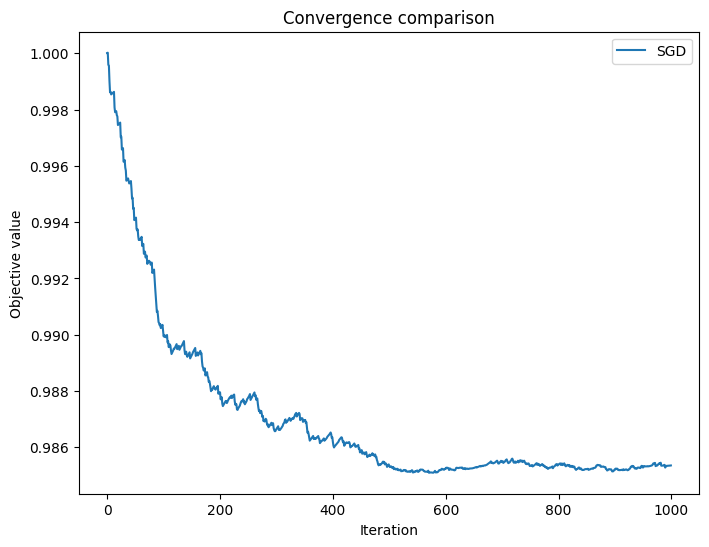

In [116]:
plot_convergence(
    [sgd_model],
    ["SGD"]
)

In [122]:
models = [
    ("SGD", SGDBaseline(kernel=RBFKernel(gamma_rbf=2.0), eta=0.005),
     {"max_iter": 1000, "precompute_kernel": False}),
    ("Pegasos", PegasosBaseline(kernel=RBFKernel(gamma_rbf=2.0)),
     {"max_iter": 1000, "precompute_kernel": False}),
    ("SCS", StochasticConjugateSubgradientAlgorithm(kernel=RBFKernel(gamma_rbf=2.0)),
     {"max_iter": 1000, "batch_size": 10}),
]

for name, model, fit_kwargs in models:
    start_time = time.time()
    model.fit(X_train, y_train, **fit_kwargs, record_history = False)
    end_time = time.time()
    model.fit(X_train, y_train, **fit_kwargs, record_history = True)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} (record history True)")
    print(f"Accuracy: {acc:.4f}")
    print(f"Time taken: {end_time - start_time:.4f} seconds\n")

SGD (record history True)
Accuracy: 0.9882
Time taken: 0.7338 seconds

Pegasos (record history True)
Accuracy: 0.9877
Time taken: 0.3944 seconds



/Users/michalwietecki/Desktop/pw/8_sem/optimization/new_repo/Stochastic_Conjugete_subgradient_algorithm_for_kernel_SVM/models/SCS.py:113: RuntimeWarning: invalid value encountered in multiply
  predictions.append(1 if score >= 0 else -1)
/Users/michalwietecki/Desktop/pw/8_sem/optimization/new_repo/Stochastic_Conjugete_subgradient_algorithm_for_kernel_SVM/models/SCS.py:116: RuntimeWarning: invalid value encountered in scalar multiply
  def eval_f(alpha,Q,W):
/Users/michalwietecki/Desktop/pw/8_sem/optimization/new_repo/Stochastic_Conjugete_subgradient_algorithm_for_kernel_SVM/models/SCS.py:131: RuntimeWarning: invalid value encountered in scalar multiply
  int_L,int_R = check_intersect(t)
/Users/michalwietecki/Desktop/pw/8_sem/optimization/new_repo/Stochastic_Conjugete_subgradient_algorithm_for_kernel_SVM/models/SCS.py:51: RuntimeWarning: invalid value encountered in multiply
  d_vec=-self._nr_operation(d_k,g_k)


Insufficient samples remaining to construct validation batch T_k.
Insufficient samples remaining to construct validation batch T_k.
SCS (record history True)
Accuracy: 0.9062
Time taken: 0.2236 seconds

